# 3-D Cantilever RC Column — pyGmsh Workflow

**Geometry** → square cross-section 0.30 m × 0.30 m × 3.00 m (W × D × H), built from a single OCC box.

| Step | What happens |
|------|-------------|
| 1 | Create geometry (OCC box) |
| 2 | Inspect geometry — entity tables, surface normals, inertia |
| 3 | Generate 3-D tet mesh (HXT algorithm) + Netgen smoothing |
| 4 | Define physical groups (Concrete, Fixed, TopFace) |
| 5 | Visualise BRep geometry with entity-tag labels |
| 6 | Visualise mesh quality (minSICN colormap) |
| 7 | Build OpenSees model (ElasticIsotropic, FourNodeTetrahedron) |
| 8 | Export to `column.msh`, `column.tcl`, `column.py` |

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from pyGmsh import pyGmsh
from Mesh   import Algorithm3D, OptimizeMethod

# ── Geometry ──────────────────────────────────────────────────────────────
W, D, H = 0.30, 0.30, 3.00   # column width, depth, height  [m]
LC      = 0.07                # target element size           [m]

# ── Material ──────────────────────────────────────────────────────────────
E_C  = 30.0e9   # Young's modulus  [Pa]
NU   = 0.20     # Poisson's ratio
RHO  = 2400.0   # density          [kg/m³]
G    = 9.81     # gravity          [m/s²]

# ── Loads ─────────────────────────────────────────────────────────────────
WIND_FORCE = 5.0e3   # lateral wind force per top-face node [N]

print("Imports OK")

Imports OK


## 1 · Initialize Gmsh session

We use the explicit `initialize()` / `finalize()` style so the session stays alive across all cells.  
Run the **last cell** (`g.finalize()`) when you are done.

In [2]:
g = pyGmsh(model_name="CantileverColumn", verbose=False)
g.initialize()
print(f"Gmsh session open — model: {g.model_name}")

Gmsh session open — model: CantileverColumn


## 2 · Create geometry

A single OCC box gives us 8 corner points, 12 edges, 6 faces and 1 volume.

In [3]:
col = g.model.add_box(0.0, 0.0, 0.0, W, D, H)
g.model.sync()
print(f"Box volume tag : {col}")
print(f"Column dims    : {W} m × {D} m × {H} m")

Box volume tag : 1
Column dims    : 0.3 m × 0.3 m × 3.0 m


## 3 · Geometry inspection

`g.inspect.get_geometry_info()` queries OCC analytically (no mesh needed).  
It returns a nested `mapping` dict with a flat DataFrame per dimension, plus a cross-dimension `global_summary`.

In [4]:
mapping, global_summary = g.inspect.get_geometry_info()

print("── Global entity summary ──")
global_summary

── Global entity summary ──


,,count
entity,type,
curves,Line,12
points,Point,8
surfaces,Plane,6
volumes,Volume,1


In [5]:
print("── Point coordinates ──")
mapping['points']['df']

── Point coordinates ──


,tag,type,x,y,z
name,,,,,
Point 1,1,Point,0.0,0.0,3.0
Point 2,2,Point,0.0,0.0,0.0
Point 3,3,Point,0.0,0.3,3.0
Point 4,4,Point,0.0,0.3,0.0
Point 5,5,Point,0.3,0.0,3.0
Point 6,6,Point,0.3,0.0,0.0
Point 7,7,Point,0.3,0.3,3.0
Point 8,8,Point,0.3,0.3,0.0


In [6]:
print("── Curve table (length, endpoints) ──")
cols = ['tag', 'type', 'length', 'start_x', 'start_y', 'start_z', 'end_x', 'end_y', 'end_z']
mapping['curves']['df'][cols]

── Curve table (length, endpoints) ──


,tag,type,length,start_x,start_y,start_z,end_x,end_y,end_z
name,,,,,,,,,
Curve 1,1,Line,3.0,0.0,0.0,0.0,0.0,0.0,3.0
Curve 2,2,Line,0.3,0.0,0.0,3.0,0.0,0.3,3.0
Curve 3,3,Line,3.0,0.0,0.3,0.0,0.0,0.3,3.0
Curve 4,4,Line,0.3,0.0,0.0,0.0,0.0,0.3,0.0
Curve 5,5,Line,3.0,0.3,0.0,0.0,0.3,0.0,3.0
Curve 6,6,Line,0.3,0.3,0.0,3.0,0.3,0.3,3.0
Curve 7,7,Line,3.0,0.3,0.3,0.0,0.3,0.3,3.0
Curve 8,8,Line,0.3,0.3,0.0,0.0,0.3,0.3,0.0
Curve 9,9,Line,0.3,0.0,0.0,0.0,0.3,0.0,0.0


In [7]:
print("── Surface table (area, centre-of-mass, normal) ──")
surf_df = mapping['surfaces']['df']
surf_df[['tag', 'type', 'area', 'cx', 'cy', 'cz', 'nx', 'ny', 'nz']]

── Surface table (area, centre-of-mass, normal) ──


,tag,type,area,cx,cy,cz,nx,ny,nz
name,,,,,,,,,
Surface 1,1,Plane,0.90,0.00,0.15,1.5,-1.0,0.0,0.0
Surface 2,2,Plane,0.90,0.30,0.15,1.5,1.0,-0.0,-0.0
Surface 3,3,Plane,0.90,0.15,0.00,1.5,0.0,-1.0,-0.0
Surface 4,4,Plane,0.90,0.15,0.30,1.5,-0.0,1.0,0.0
Surface 5,5,Plane,0.09,0.15,0.15,0.0,-0.0,0.0,-1.0
Surface 6,6,Plane,0.09,0.15,0.15,3.0,0.0,-0.0,1.0


In [8]:
print("── Volume properties ──")
vol_df = mapping['volumes']['df']
vol_df[['tag', 'type', 'volume', 'cx', 'cy', 'cz', 'ixx', 'iyy', 'izz']]

── Volume properties ──


,tag,type,volume,cx,cy,cz,ixx,iyy,izz
name,,,,,,,,,
Volume 1,1,Volume,0.27,0.15,0.15,1.5,0.204525,0.204525,0.00405


In [9]:
# Inertia tensor of the volume (from g.inspect.entity)
vol_info = g.inspect.entity(3, col)
print("Inertia tensor [kg·m²]:")
print(vol_info['inertia'])

Inertia tensor [kg·m²]:
[[ 2.0452500e-01  0.0000000e+00 -6.9388939e-18]
 [ 0.0000000e+00  2.0452500e-01  0.0000000e+00]
 [-6.9388939e-18  0.0000000e+00  4.0500000e-03]]


### Identify bottom and top faces

Filter the surface DataFrame by centre-of-mass Z coordinate.

In [10]:
tol     = 1e-6
bot_tag = int(surf_df.loc[surf_df['cz'].abs()       < tol, 'tag'].iloc[0])
top_tag = int(surf_df.loc[(surf_df['cz'] - H).abs() < tol, 'tag'].iloc[0])

print(f"Bottom face  →  surface tag {bot_tag}  (cz ≈ 0.00 m)")
print(f"Top    face  →  surface tag {top_tag}  (cz ≈ {H:.2f} m)")

Bottom face  →  surface tag 5  (cz ≈ 0.00 m)
Top    face  →  surface tag 6  (cz ≈ 3.00 m)


## 4 · Geometry plot

BRep visualisation via parametric UV sampling — no mesh involved.  
Surface tags are annotated at each face centroid.

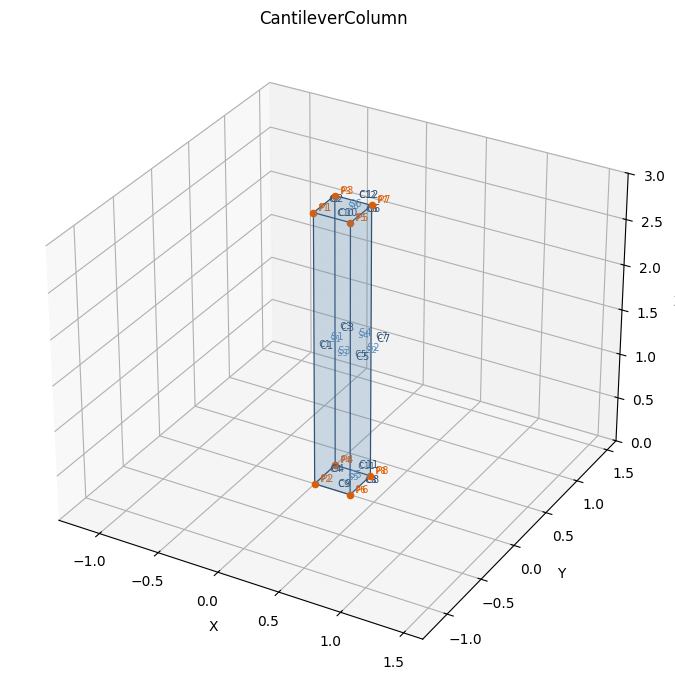

In [11]:
(g.plot
   .geometry(
       show_surfaces=True,
       surface_alpha=0.15,
       label_tags=True,
       show=False,
   )
   .label_entities(dims=[0, 1, 2], show=False))

plt.tight_layout()
plt.show()

## 5 · Mesh generation

3-D tetrahedral mesh using the **HXT** algorithm (fast, high-quality), followed by **Netgen** smoothing.

In [12]:
(g.mesh
   .set_global_size(LC)
   .set_algorithm(0, Algorithm3D.HXT, dim=3)
   .generate(3)
   .optimize(OptimizeMethod.NETGEN, niter=3))

node_info = g.mesh.get_nodes()
print(f"Nodes generated : {len(node_info['tags'])}")

Nodes generated : 1353


## 6 · Physical groups

In [13]:
(g.physical
   .add_volume( [col],      name="Concrete")
   .add_surface([bot_tag],  name="Fixed")
   .add_surface([top_tag],  name="TopFace"))

print("── Physical group summary ──")
g.physical.summary()

── Physical group summary ──


name  n_entities entity_tags
dim pg_tag                                  
2   2          Fixed           1           5
    3        TopFace           1           6
3   1       Concrete           1           1

In [14]:
# How many mesh nodes belong to each boundary group?
fixed_nodes   = g.physical.get_nodes(2, g.physical.get_tag(2, "Fixed"))
topface_nodes = g.physical.get_nodes(2, g.physical.get_tag(2, "TopFace"))

print(f"Fixed   face nodes : {len(fixed_nodes['tags'])}")
print(f"TopFace face nodes : {len(topface_nodes['tags'])}")

Fixed   face nodes : 44
TopFace face nodes : 44


## 7 · Mesh quality report

Statistics on the **minSICN** (signed inverse condition number) — the default Gmsh quality measure.  
Values range from −1 (inverted) to 1 (perfect); > 0.2 is generally acceptable.

In [15]:
qdf = g.mesh.quality_report()
print("── Mesh quality statistics ──")
qdf

── Mesh quality statistics ──


,dim,n_elements,min,mean,max
type,,,,,
Triangle 3,2,1976,0.894200,0.976788,1.000000
Tetrahedron 4,3,4710,0.427631,0.822253,0.995363


## 8 · Mesh visualisation

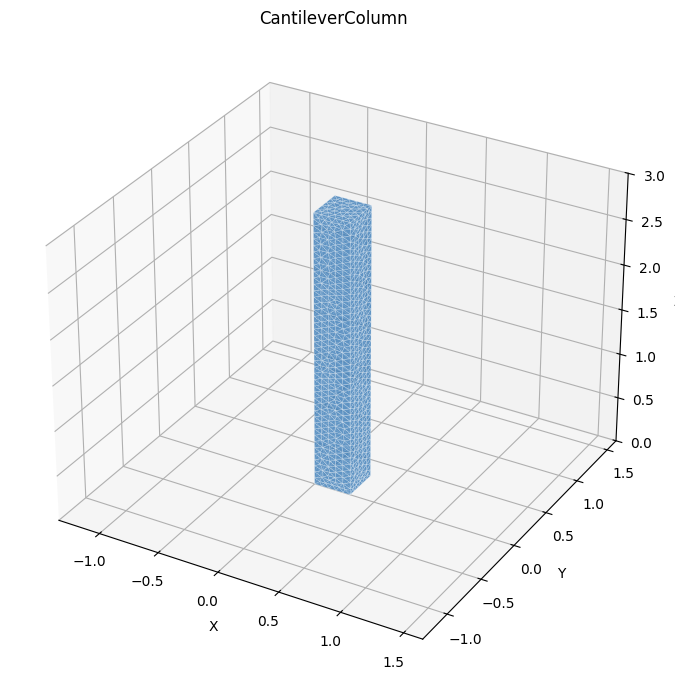

In [16]:
g.plot.clear()
g.plot.mesh(alpha=0.55, edge_color='white', linewidth=0.25, show=False)
plt.tight_layout()
plt.show()

## 9 · Mesh quality plot

Surface elements coloured by minSICN — green = high quality, red = poor.

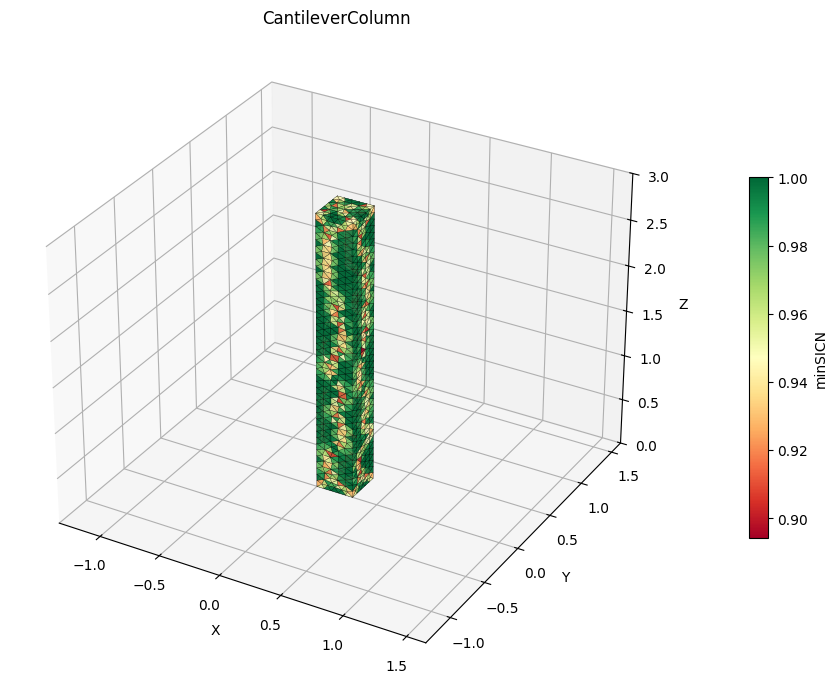

In [17]:
g.plot.clear()
g.plot.quality(quality_name="minSICN", cmap="RdYlGn", show=False)
plt.tight_layout()
plt.show()

## 10 · Save mesh

In [18]:
g.mesh.save("column.msh")
print("Mesh written → column.msh")

Mesh written → column.msh


## 11 · OpenSees model

| Declaration | Value |
|-------------|-------|
| Model space | 3-D, 3 DOF/node |
| Material | `ElasticIsotropic` concrete (E = 30 GPa, ν = 0.20, ρ = 2400 kg/m³) |
| Elements | `FourNodeTetrahedron` with body force (self-weight in −Z) |
| Boundary | Fixed base — all 3 DOFs restrained |
| Load | Lateral wind 5 kN per top-face node (+X direction) |

In [19]:
(g.opensees
   .set_model(ndm=3, ndf=3)

   .add_nd_material(
       "Concrete", "ElasticIsotropic",
       E=E_C, nu=NU, rho=RHO,
   )

   .assign_element(
       "Concrete", "FourNodeTetrahedron",
       material="Concrete",
       bodyForce=[0.0, 0.0, -RHO * G],
   )

   .fix("Fixed", dofs=[1, 1, 1])

   .add_nodal_load("Wind", "TopFace", force=[WIND_FORCE, 0.0, 0.0])

   .build()
)

print("Build complete")

Build complete


In [20]:
print(g.opensees.summary())

OpenSees bridge — model: 'CantileverColumn'
  ndm=3  ndf=3

  nDMaterials (1):
    [1] 'Concrete'  →  ElasticIsotropic  E=30000000000.0  nu=0.2  rho=2400.0
  uniaxialMaterials (0):
  Sections (0):
  GeomTransfs (0):

  Element assignments (1):
    PG 'Concrete'  →  FourNodeTetrahedron  (mat='Concrete')  bodyForce=[0.0, 0.0, -23544.0]

  Boundary conditions (1):
    PG 'Fixed'  →  fix [1, 1, 1]

  Load patterns (1):
    'Wind'  PG 'TopFace'  nodal  force=[5000.0, 0.0, 0.0]

  ── built ──
  nodes    : 2791
  elements : 4710
    FourNodeTetrahedron               PG 'Concrete'  n=4710


In [21]:
df_nodes = g.opensees.node_table()
print(f"Total nodes : {len(df_nodes)}")
df_nodes.head(10)

Total nodes : 2791


,x,y,z
ops_id,,,
1,0.0,0.0,3.000000
2,0.0,0.0,0.000000
3,0.0,0.3,3.000000
4,0.0,0.3,0.000000
5,0.3,0.0,3.000000
6,0.3,0.0,0.000000
7,0.3,0.3,3.000000
8,0.3,0.3,0.000000
9,0.0,0.0,0.069767


In [22]:
df_elems = g.opensees.element_table()
print(f"Total elements : {len(df_elems)}")
print("\nElement type breakdown:")
print(df_elems.groupby('ops_type').size().to_string())
df_elems.head(8)

Total elements : 4710

Element type breakdown:
ops_type
FourNodeTetrahedron    4710


,gmsh_id,ops_type,pg_name,mat_name,mat_tag,sec_tag,transf_tag,n_nodes,nodes,slots,extra
ops_id,,,,,,,,,,,
1,2197,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1685, 2344, 1440, 1439)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
2,2198,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1441, 2324, 2317, 2279)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
3,2199,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1442, 2387, 2524, 2469)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
4,2200,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1443, 1444, 1445, 2428)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
5,2201,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1446, 1930, 1856, 1980)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
6,2202,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1447, 1448, 1449, 1450)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
7,2203,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1451, 1452, 1453, 1454)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"
8,2204,FourNodeTetrahedron,Concrete,Concrete,1,None,None,4,"(1455, 1445, 1456, 1444)","(nodes, matTag, bodyForce)","{'bodyForce': [0.0, 0.0, -23544.0]}"


### Fixed-DOF nodes (sample)

In [23]:
fixed_mask = df_nodes[['fix_1', 'fix_2', 'fix_3']].any(axis=1)
df_fixed   = df_nodes[fixed_mask]
print(f"Fixed nodes : {len(df_fixed)}")
df_fixed.head(8)

KeyError: "None of [Index(['fix_1', 'fix_2', 'fix_3'], dtype='str')] are in the [columns]"

### Loaded nodes (sample)

In [ ]:
load_cols = [c for c in df_nodes.columns if c.startswith('load_')]
if load_cols:
    loaded_mask = df_nodes[load_cols].any(axis=1)
    df_loaded   = df_nodes[loaded_mask]
    print(f"Loaded nodes : {len(df_loaded)}")
    display(df_loaded.head(8))
else:
    print("No load columns found in node table")

## 12 · Export OpenSees scripts

In [ ]:
(g.opensees
   .export_tcl("column.tcl")
   .export_py ("column.py"))

print("Written → column.tcl")
print("Written → column.py")

### Preview — first 40 lines of column.tcl

In [ ]:
with open("column.tcl") as f:
    lines = f.readlines()
print(f"Total lines : {len(lines)}\n")
print("".join(lines[:40]))

### Preview — first 40 lines of column.py

In [ ]:
with open("column.py") as f:
    lines = f.readlines()
print(f"Total lines : {len(lines)}\n")
print("".join(lines[:40]))

## 13 · Finalize Gmsh session

Always call `finalize()` when using the explicit style — this frees all Gmsh resources.

In [ ]:
g.finalize()
print("Gmsh session closed.")